# CIFAR-10 Notebook
This notebook is a cell-by-cell conversion of `mainCIFAR.py`. Run cells in order.
https://colab.research.google.com/github/pytorch/tutorials/blob/gh-pages/_downloads/cifar10_tutorial.ipynb#scrollTo=FZU_97FEtobo

In [3]:
# Imports
import torch
import torchvision
import torchvision.transforms as transforms

In [4]:
# Define transforms - note: Normalize maps [0,1] -> [-1,1]
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

In [5]:
# Load CIFAR-10 training dataset
trainset = torchvision.datasets.CIFAR10(root="./data", train=True, download=False, transform=transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=4, shuffle=True, num_workers=2)

testset = torchvision.datasets.CIFAR10(root="./data", train=False, download=False, transform=transform)
testloader = torch.utils.data.DataLoader(testset, batch_size=4, shuffle=False, num_workers=2)

classes = ('plane', 'car', 'bird', 'cat',
           'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

  dog   dog  frog  bird


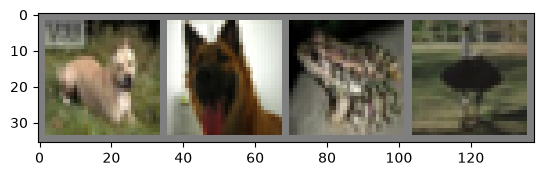

In [21]:
import matplotlib.pyplot as plt
import numpy as np

#functions to show an image

def imshow(img):
    img = img / 2 + 0.5   #unnormalise
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1,2,0)))

#get random training images
dataiter = iter(trainloader)
images, labels = next(dataiter)

#show images
imshow(torchvision.utils.make_grid(images))
#print labels
print(" ".join("%5s" % classes[labels[j]] for j in range(4)))

In [13]:
import torch.nn as nn 
import torch.nn.functional as F 

class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()
        self.conv1 = nn.Conv2d(3, 6, 5)
        #3 input channels (RGB)
        #6 output channels (layer learns 6 filters)
        #kernel size 5x5
        self.pool = nn.MaxPool2d(2,2) #downsizes the feature map. kernal size=2, stride=2
        self.conv2 = nn.Conv2d(6, 16, 5)

        self.fc1 = nn.Linear(16 * 5 * 5, 120)  #fully connected layer maps flattened feature to 120 outputs
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))  #intros non-linearity
        x = self.pool(F.relu(self.conv2(x)))
        x = x.view(-1, 16 *5*5)  #takes x from 4D to 2D to be passed into connected layer
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x
    
net = Net()

In [ ]:
import torch.optim as optim

#defining loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(net.parameters(), lr=0.001, momentum=0.9)

In [20]:
for epoch in range(2):  #loop over dataset multiple times

    running_loss = 0.0
    for i, data in enumerate(trainloader, 0):
        #get the inputs
        inputs, labels = data

        #zero the parameter gradients
        optimizer.zero_grad()

        #forward + backward + optimize
        outputs = net(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        #print statistics
        running_loss += loss.item()
        if i % 2000 == 1999:
            print("[%d, %5d] loss: %.3f" % (epoch + 1, i + 1, running_loss / 2000))
            running_loss = 0.0

print("Training Finished")

[1,  2000] loss: 1.331
[1,  4000] loss: 1.347
[1,  6000] loss: 1.334
[1,  8000] loss: 1.327
[1, 10000] loss: 1.356
[1, 12000] loss: 1.352
[2,  2000] loss: 1.319
[2,  4000] loss: 1.352
[2,  6000] loss: 1.330
[2,  8000] loss: 1.327
[2, 10000] loss: 1.366
[2, 12000] loss: 1.353
Training Finished


In [22]:
dataiter = iter(testloader)
images, labels = dataiter.next()

#print images
imshow(torchvision.utils.make_grid(images))
print("Ground truth: "," ".join("%5s" % classes[labels[j]] for j in range(4)))

AttributeError: '_MultiProcessingDataLoaderIter' object has no attribute 'next'